<a href="https://colab.research.google.com/github/Surhan-Memon/Industrial_IoT_Fault_Detection_Dataset/blob/main/Industrial_IoT_Fault_Detection_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df = pd.read_csv('/content/industrial_fault_detection_data_1000.csv')

In [96]:
df.head()

,Timestamp,Vibration (mm/s),Temperature (°C),Pressure (bar),RMS Vibration,Mean Temp,Fault Label
0,2023-03-10 00:00:00,0.437086,64.810634,7.785117,0.601657,90.561384,1
1,2023-03-10 00:01:00,0.955643,93.352076,7.740936,0.601657,90.561384,1
2,2023-03-10 00:02:00,0.758795,119.835667,9.718764,0.601657,90.561384,0
3,2023-03-10 00:03:00,0.638793,108.577991,7.748639,0.601657,90.561384,1
4,2023-03-10 00:04:00,0.240417,114.524892,7.815849,0.601657,90.561384,0


In [97]:
missing_value = df.isnull().sum()
missing_value

,0
Timestamp,0
Vibration (mm/s),0
Temperature (°C),0
Pressure (bar),0
RMS Vibration,0
Mean Temp,0
Fault Label,0


In [98]:
df.columns

Index(['Timestamp', 'Vibration (mm/s)', 'Temperature (°C)', 'Pressure (bar)',
       'RMS Vibration', 'Mean Temp', 'Fault Label'],
      dtype='object')

In [99]:
df.shape

(1000, 7)

In [100]:
df = df.drop(columns=['Timestamp'])

In [101]:
df

,Vibration (mm/s),Temperature (°C),Pressure (bar),RMS Vibration,Mean Temp,Fault Label
0,0.437086,64.810634,7.785117,0.601657,90.561384,1
1,0.955643,93.352076,7.740936,0.601657,90.561384,1
2,0.758795,119.835667,9.718764,0.601657,90.561384,0
3,0.638793,108.577991,7.748639,0.601657,90.561384,1
4,0.240417,114.524892,7.815849,0.601657,90.561384,0
...,...,...,...,...,...,...
995,0.182424,102.556413,9.595887,0.601657,90.561384,0
996,0.925582,126.529170,7.471820,0.601657,90.561384,0
997,0.223137,55.516641,7.929364,0.601657,90.561384,0
998,0.955214,54.564378,7.870137,0.601657,90.561384,0


In [102]:
#Split features
X = df.drop(columns=['Fault Label'])
y = df['Fault Label']

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [104]:
print(X_train.shape, X_test.shape)

(800, 5) (200, 5)


In [116]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [117]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.57
              precision    recall  f1-score   support

           0       0.58      0.96      0.72       115
           1       0.50      0.06      0.11        66
           2       0.00      0.00      0.00        19

    accuracy                           0.57       200
   macro avg       0.36      0.34      0.28       200
weighted avg       0.50      0.57      0.45       200



In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [119]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [120]:
y_pred = model.predict(X_test_scaled)

In [121]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.575
              precision    recall  f1-score   support

           0       0.57      1.00      0.73       115
           1       0.00      0.00      0.00        66
           2       0.00      0.00      0.00        19

    accuracy                           0.57       200
   macro avg       0.19      0.33      0.24       200
weighted avg       0.33      0.57      0.42       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: title={'center': 'Feature Importance'}>

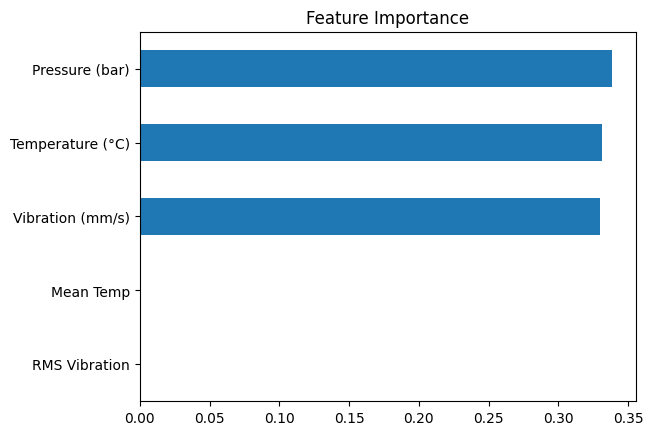

In [115]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', title="Feature Importance")